**MCMC Simulation using the Random Walk Metropolis–Hastings Algorithm**

In this task, we apply the Markov Chain Monte Carlo (MCMC) method, specifically the Random Walk Metropolis–Hastings algorithm, to generate samples from a given probability density function. Using the generated samples, we estimate the shape of the distribution through a histogram and kernel density plot and compare these with the true density function. We also compute the Monte Carlo estimates of the mean and standard deviation to assess how well the algorithm approximates the target distribution.

**Importing Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Step 1: Define target density f(x)**

**f(x) = (1/2) * exp(-|x|)**

In [ ]:
def f(x):
    return 0.5 * np.exp(-np.abs(x))

In [ ]:
# log version (This avoids numerical errors)
def log_f(x):
    return -np.abs(x) - np.log(2)

**Step 2 : Setting parameters**

In [ ]:
N = 10000       # number of samples
s = 1           # standard deviation (proposal)
x = np.zeros(N) # store samples

# initial value x0
x[0] = 0

**Step 3 : Metropolis-Hastings**

In [ ]:
for i in range(1, N):    #Each iteration generates one new sample

    # propose new value
    x_star = np.random.normal(x[i-1], s)

    # log acceptance ratio
    log_r = log_f(x_star) - log_f(x[i-1])

    # sample u
    u = np.random.uniform(0, 1)

    # accept/reject
    if np.log(u) < log_r:
        x[i] = x_star
    else:
        x[i] = x[i-1]

**Step 4: Plotting Histogram + KDE + true f(x)**

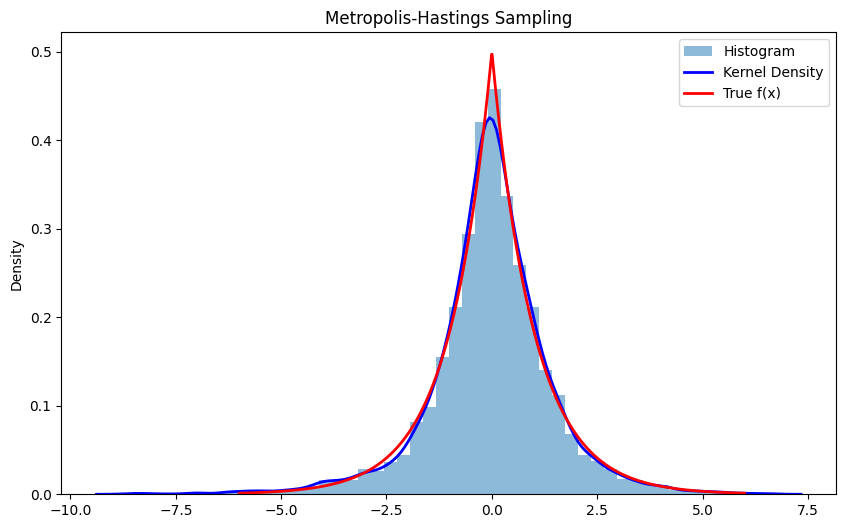

In [ ]:
x_vals = np.linspace(-6, 6, 1000)   #Creates 1000 points between -6 and 6

plt.figure(figsize=(10,6))   #Creates a figure

# histogram
plt.hist(x, bins=50, density=True, alpha=0.5, label='Histogram')   #Shows distribution of generated samples

# KDE
sns.kdeplot(x, color='blue', linewidth=2, label='Kernel Density')   #Smooth version of histogram

# true density
plt.plot(x_vals, f(x_vals), 'r-', lw=2, label='True f(x)')  #This codes the actual distribution

plt.title('Metropolis-Hastings Sampling')   #Adds title, legend, and displays plot
plt.legend()
plt.show()

**Step 5 : Monte Carlo Estimates**



In [ ]:
mean_est = np.mean(x)
std_est = np.std(x)

print("Sample Mean:", mean_est)
print("Sample Std Dev:", std_est)

Sample Mean: -0.03321060069041721
Sample Std Dev: 1.439942395533526
